# VOLTA · 04 — Decision engine

**Raw LP schedule → CHARGE / DISCHARGE / HOLD cards a human can read**

The optimizer is silent. The desk is not. Each hour gets:

- an **action**
- a **why** (plain English, with the numbers)
- **confidence** from the P10–P90 band
- **expected €**
- **flags** — `BELOW_BREAKEVEN`, `HIGH_UNCERTAINTY`, `SPIKE`

Risk scales the *whole day* (never a single hour) so SOC physics stay feasible.

`src/decisions.py` is what the Streamlit app will import.


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ROOT = Path.cwd()
if not (ROOT / "src" / "config.py").exists():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "config.py").exists():
            ROOT = p
            break
sys.path.insert(0, str(ROOT))

from src.config import CACHE
from src.decisions import decide_day, decide_range, breakeven_spread
from src.optimizer import DEFAULT_BATTERY

FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
TEAL, AMBER, NAVY, SLATE, RED = "#0D9488", "#D97706", "#0F172A", "#64748B", "#DC2626"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#E2E8F0", "axes.grid": True, "grid.color": "#F1F5F9",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "semibold",
    "figure.dpi": 120, "savefig.dpi": 160, "legend.frameon": False,
})


def savefig(fig, name):
    fig.savefig(FIG / name, bbox_inches="tight", facecolor="white")
    print("saved", (FIG / name).relative_to(ROOT))

print("breakeven at €50 buy:", round(breakeven_spread(50), 2), "€/MWh")
print(DEFAULT_BATTERY)


breakeven at €50 buy: 9.82 €/MWh
BatteryParams(power_mw=100.0, capacity_mwh=200.0, round_trip=0.88, min_soc_pct=0.1, max_cycles_per_day=1.0, degradation_eur_per_mwh=3.0)


### Rule cascade

1. Solve the daily LP on **P50**.
2. If forecast spread < round-trip + €3/MWh degradation → **HOLD the day** (`BELOW_BREAKEVEN`).
3. If median (P90−P10)/P50 ≥ 0.45 → size to 25%. If ≥ 0.25 → size to 50% (`HIGH_UNCERTAINTY`).
4. Hours with P50 ≥ €90 or ≥ day mean + 2σ get `SPIKE` — a label, not a silent rewrite.
5. Rank cards by |expected €|; HOLDs last.

Hour-level edits would break energy balance. We don't do them.


In [2]:
# A clean two-peak-less day: cheap night, expensive evening, tight bands.
idx = pd.date_range("2018-06-12", periods=24, freq="h", tz="Europe/Madrid")
p50 = pd.Series(np.concatenate([np.full(8, 22.0), np.linspace(30, 55, 8), np.full(8, 78.0)]), index=idx)
p10, p90 = p50 - 4, p50 + 4
d = decide_day(p50, p10, p90)
print("scale", d.scale, "flags", d.day_flags, "expected €", round(d.expected_eur, 1))
print("spread €", round(d.spread_eur, 2), "breakeven €", round(d.breakeven_eur, 2))
show = d.cards.sort_values("rank")[["action", "mw", "price_p50", "confidence", "expected_eur", "flags", "why"]]
display(show.head(8))


scale 1.0 flags [] expected € 8442.7
spread € 56.0 breakeven € 6.0


,action,mw,price_p50,confidence,expected_eur,flags,why
ts,,,,,,,
2018-06-12 18:00:00+02:00,DISCHARGE,100.00,78.00,0.79,"7,500.00",,DISCHARGE 100 MW at 18:00 into P50 €78.0/MWh (day €22.0–€78.0). Spread €56.0 vs breakeven €6.0. Confidence 79%.
2018-06-12 17:00:00+02:00,DISCHARGE,68.85,78.00,0.79,"5,164.12",,DISCHARGE 69 MW at 17:00 into P50 €78.0/MWh (day €22.0–€78.0). Spread €56.0 vs breakeven €6.0. Confidence 79%.
2018-06-12 06:00:00+02:00,CHARGE,100.00,22.00,0.27,"-2,200.00",,CHARGE 100 MW at 06:00. P50 €22.0/MWh is near the day's floor (€22.0–€78.0). Fill now; sell the peak. Spread €56.0 v...
2018-06-12 07:00:00+02:00,CHARGE,91.88,22.00,0.27,"-2,021.37",,CHARGE 92 MW at 07:00. P50 €22.0/MWh is near the day's floor (€22.0–€78.0). Fill now; sell the peak. Spread €56.0 vs...
2018-06-12 00:00:00+02:00,HOLD,0.00,22.00,0.27,0.00,,"HOLD at 00:00. LP has no flow here (forecast €22.0, day range €22.0–€78.0)."
2018-06-12 01:00:00+02:00,HOLD,0.00,22.00,0.27,0.00,,"HOLD at 01:00. LP has no flow here (forecast €22.0, day range €22.0–€78.0)."
2018-06-12 02:00:00+02:00,HOLD,0.00,22.00,0.27,0.00,,"HOLD at 02:00. LP has no flow here (forecast €22.0, day range €22.0–€78.0)."
2018-06-12 03:00:00+02:00,HOLD,0.00,22.00,0.27,0.00,,"HOLD at 03:00. LP has no flow here (forecast €22.0, day range €22.0–€78.0)."


saved notebooks/figures/30_example_day.png


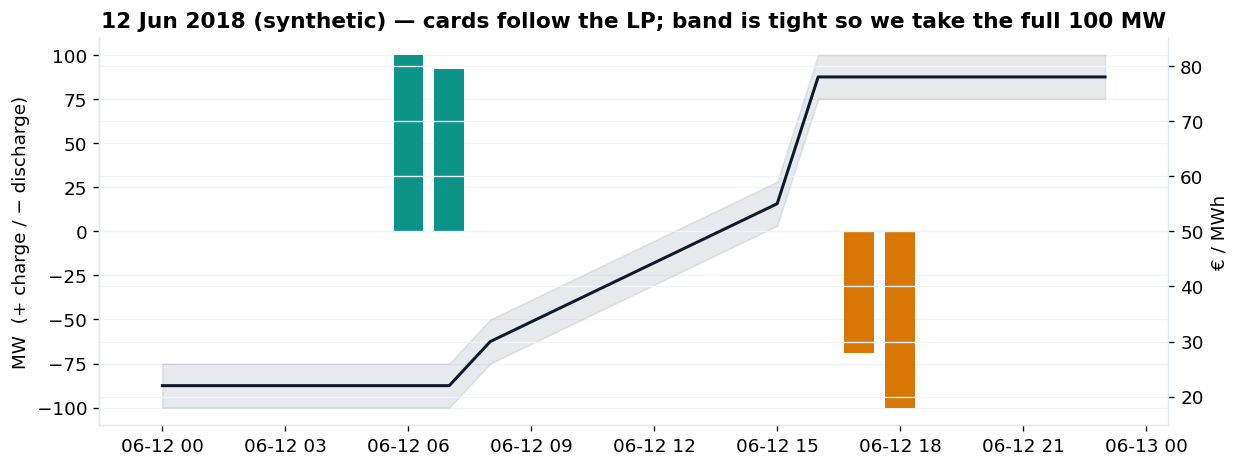

top why:
DISCHARGE 100 MW at 18:00 into P50 €78.0/MWh (day €22.0–€78.0). Spread €56.0 vs breakeven €6.0. Confidence 79%.


In [3]:
fig, ax = plt.subplots(figsize=(11.5, 4.2))
c = d.cards
colors = c["action"].map({"CHARGE": TEAL, "DISCHARGE": AMBER, "HOLD": "#CBD5E1"})
signed = np.where(c["action"] == "DISCHARGE", -c["mw"], c["mw"])
ax.bar(c.index, signed, color=colors, width=0.03, zorder=3)
ax.set_ylabel("MW  (+ charge / − discharge)")
ax2 = ax.twinx()
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color("#E2E8F0")
ax2.fill_between(c.index, c["price_p10"], c["price_p90"], color=SLATE, alpha=0.15)
ax2.plot(c.index, c["price_p50"], color=NAVY, lw=1.8)
ax2.set_ylabel("€ / MWh")
ax.set_title("12 Jun 2018 (synthetic) — cards follow the LP; band is tight so we take the full 100 MW")
ax.xaxis.grid(False)
savefig(fig, "30_example_day.png")
plt.show()
print("top why:")
print(show.iloc[0]["why"])


**Insight.** The why is the product. A recruiter should be able to disagree with the trade and still see *why* the desk wanted it. Confidence is not a model-score theatre: it is the quantile width we already paid for in Phase 2.


In [4]:
# Three guardrail regimes on the same shape.
base = np.concatenate([np.full(12, 25.0), np.full(12, 70.0)])
idx = pd.date_range("2018-03-01", periods=24, freq="h", tz="Europe/Madrid")
p50 = pd.Series(base, index=idx)

tight = decide_day(p50, p50-3, p50+3)
wide = decide_day(p50, p50*0.6, p50*1.4)          # ~80% relative width
thin = decide_day(pd.Series(np.full(24, 50.0), index=idx))  # no spread

rows = pd.DataFrame([
    {"regime": "tight band, fat spread", "scale": tight.scale, "flags": "|".join(tight.day_flags) or "—",
     "n_charge": int((tight.cards.action=="CHARGE").sum()), "n_discharge": int((tight.cards.action=="DISCHARGE").sum()),
     "expected_eur": tight.expected_eur},
    {"regime": "wide band, fat spread", "scale": wide.scale, "flags": "|".join(wide.day_flags) or "—",
     "n_charge": int((wide.cards.action=="CHARGE").sum()), "n_discharge": int((wide.cards.action=="DISCHARGE").sum()),
     "expected_eur": wide.expected_eur},
    {"regime": "no spread", "scale": thin.scale, "flags": "|".join(thin.day_flags) or "—",
     "n_charge": int((thin.cards.action=="CHARGE").sum()), "n_discharge": int((thin.cards.action=="DISCHARGE").sum()),
     "expected_eur": thin.expected_eur},
])
display(rows)


,regime,scale,flags,n_charge,n_discharge,expected_eur
0,"tight band, fat spread",1.00,—,2,2,"6,516.27"
1,"wide band, fat spread",0.25,HIGH_UNCERTAINTY,2,2,"1,629.07"
2,no spread,0.00,BELOW_BREAKEVEN,0,0,0.00


---
## 2018, on the real forecast

P50 / P10 / P90 from Phase 2 (`cache/test_2018_forecasts.parquet`). One LP per day, then the cascade.


In [5]:
fc = pd.read_parquet(CACHE / "test_2018_forecasts.parquet")
print(fc.shape, fc.index.min(), "→", fc.index.max())
cards = decide_range(fc["price_p50"], fc["price_p10"], fc["price_p90"])
print("hours", len(cards), "days", cards["day"].nunique())

mix = cards["action"].value_counts(normalize=True).rename("share")
display(pd.concat([cards["action"].value_counts().rename("hours"), mix], axis=1))

flag_rows = cards["flags"].replace("", pd.NA).dropna()
exploded = flag_rows.str.split("|").explode()
print("flag counts")
print(exploded.value_counts().to_string())

out = CACHE / "action_cards_2018.parquet"
cards.to_parquet(out)
print("wrote", out.relative_to(ROOT))


(8760, 7) 2018-01-01 00:00:00+01:00 → 2018-12-31 23:00:00+01:00


hours 8760 days 365


,hours,share
action,,
HOLD,7440,0.85
CHARGE,669,0.08
DISCHARGE,651,0.07


flag counts
flags
BELOW_BREAKEVEN     1248
HIGH_UNCERTAINTY     983
SPIKE                 83
wrote cache/action_cards_2018.parquet


saved notebooks/figures/31_2018_actions_flags.png


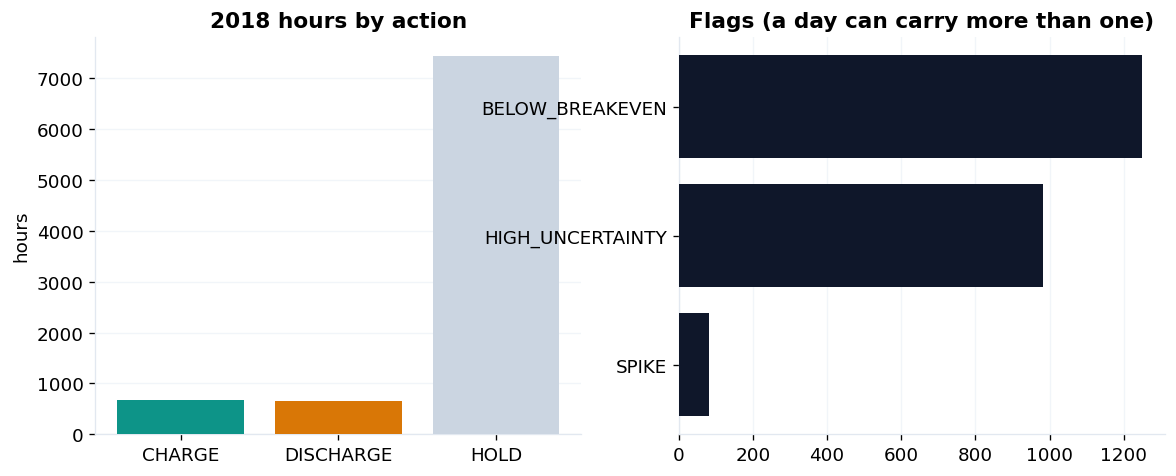

mean confidence CHARGE/DISCHARGE/HOLD
action
CHARGE      0.51
DISCHARGE   0.69
HOLD        0.64
mean |expected €| on money hours 4884.286454504319


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
vc = cards["action"].value_counts().reindex(["CHARGE", "DISCHARGE", "HOLD"])
axes[0].bar(vc.index, vc.values, color=[TEAL, AMBER, "#CBD5E1"], zorder=3)
axes[0].set_title("2018 hours by action")
axes[0].set_ylabel("hours")
axes[0].xaxis.grid(False)

fc_counts = exploded.value_counts()
axes[1].barh(fc_counts.index[::-1], fc_counts.values[::-1], color=NAVY, zorder=3)
axes[1].set_title("Flags (a day can carry more than one)")
axes[1].xaxis.grid(True)
axes[1].yaxis.grid(False)
savefig(fig, "31_2018_actions_flags.png")
plt.show()

print("mean confidence CHARGE/DISCHARGE/HOLD")
print(cards.groupby("action")["confidence"].mean().round(3).to_string())
print("mean |expected €| on money hours",
      cards.loc[cards.action != "HOLD", "expected_eur"].abs().mean())


### Two real days — the cards a trader would see


In [7]:
def show_day(day):
    sl = cards.loc[str(day)]
    money = sl.sort_values("rank")
    money = money[money["action"] != "HOLD"].head(6)
    print("=" * 72)
    print(day, " scale", float(sl["scale"].iloc[0]),
          " day €", round(float(sl["day_expected_eur"].iloc[0]), 1),
          " flags", sl["flags"].iloc[0] or "—")
    display(money[["action", "mw", "price_p50", "confidence", "expected_eur", "why"]])

show_day("2018-01-25")
show_day("2018-07-15")


2018-01-25  scale 1.0  day € 944.0  flags —


,action,mw,price_p50,confidence,expected_eur,why
ts,,,,,,
2018-01-25 20:00:00+01:00,DISCHARGE,100.00,68.65,0.76,"6,564.87",DISCHARGE 100 MW at 20:00 into P50 €68.6/MWh (day €52.7–€68.6). Spread €15.8 vs breakeven €10.2. Confidence 76%.
2018-01-25 04:00:00+01:00,CHARGE,100.00,52.65,0.63,"-5,265.23",CHARGE 100 MW at 04:00. P50 €52.7/MWh is near the day's floor (€52.7–€68.6). Fill now; sell the peak. Spread €15.8 v...
2018-01-25 05:00:00+01:00,CHARGE,91.88,52.84,0.63,"-4,854.91",CHARGE 92 MW at 05:00. P50 €52.8/MWh is near the day's floor (€52.7–€68.6). Fill now; sell the peak. Spread €15.8 vs...
2018-01-25 19:00:00+01:00,DISCHARGE,68.85,68.34,0.77,"4,499.22",DISCHARGE 69 MW at 19:00 into P50 €68.3/MWh (day €52.7–€68.6). Spread €15.8 vs breakeven €10.2. Confidence 77%.


2018-07-15  scale 0.0  day € 0.0  flags BELOW_BREAKEVEN


,action,mw,price_p50,confidence,expected_eur,why
ts,,,,,,


**Insight.** 25 Jan 2018 is a squeeze cousin of the 2017 spike cluster — the engine wants the evening print and says so. Mid-July is quieter: more HOLDs, smaller €, sometimes a `HIGH_UNCERTAINTY` cut. The same code path, different weather in the band.

That is the whole point of Phase 4: the LP does not get a microphone. The cascade does.


---
## Checkpoint

| Item | Status |
|---|---|
| Engine | `src/decisions.py` — `decide_day` / `decide_range` |
| Tests | `tests/test_decisions.py` — HOLD on flat, shrink on wide bands, spike is a flag not a rewrite |
| Cards | action, mw, why, confidence, expected €, flags, rank |
| Guardrails | day-level scale only (SOC stays feasible) |
| Artifact | `cache/action_cards_2018.parquet` (app seed) |

**Assumptions**

1. Confidence = `clip(1 − (P90−P10)/P50 / 0.5, 0.15, 0.98)`.
2. Soft/hard uncertainty cuts at 25% / 45% relative width.
3. Breakeven = `P_buy × (1/0.88 − 1) + €3`.
4. `SPIKE` is a warning on the card, not an override of the LP.

Next: Phase 5 — 9-page control-room app, these cards on the Dispatch page.


In [8]:
print("=" * 60)
print("VOLTA · 04 decisions checkpoint")
print("=" * 60)
print("2018 hours         ", len(cards))
print(cards["action"].value_counts().to_string())
print("mean scale         ", round(cards.groupby("day")["scale"].first().mean(), 3))
print("days below even    ", int((cards.groupby("day")["scale"].first() == 0).sum()))
print("done.")


VOLTA · 04 decisions checkpoint
2018 hours          8760
action
HOLD         7440
CHARGE        669
DISCHARGE     651
mean scale          0.796
days below even     52
done.
